# Thalassemia Multi-class Prediction Pipeline

四分类地中海贫血预测模型 —— 主运行 Notebook。

按照标准临床预测模型建模流程，依次完成：

1. Data Loading and Cleaning
2. Univariate Analysis (Normality -> Homogeneity of Variance -> ANOVA / Kruskal-Wallis)
3. Select 2-3 Best Derived Thalassemia Indices out of 9 Candidates
4. Baseline Characteristics Table Across 4 Diagnosis Groups (with Univariate P-values)
5. Stratified Train/Test Split (7:3)
6. Baseline Characteristics Comparison - Train vs Test
7. Train 7 Models with 5-fold CV Hyperparameter Tuning
8. Model Performance Comparison Table - Train vs Test
9. Test-set Bootstrap (1000 Resamples) Model Comparison Table
10. ROC Curves / Calibration Curves (with Slope & Intercept) / Decision Curves / Confusion Matrices
11. SHAP Interpretability Analysis (Summary + Bar Plots)

In [1]:
import joblib

from config import settings
from data_processing.loader import load_clean_dataset
from data_processing.splitter import stratified_split
from models.load_models import load_all_trained_models
from models.trainer import train_all_models
from stats_analysis.baseline_tables import build_group_baseline_table, build_split_baseline_table
from stats_analysis.feature_selector import select_derived_indices, build_final_feature_list
from stats_analysis.univariate import run_univariate_analysis
from visualization.calibration_plots import plot_calibration_grid, compute_calibration_summary
from visualization.confusion_matrix_plot import plot_confusion_matrix_grid
from visualization.decision_curve import plot_decision_curve_grid
from visualization.roc_plots import plot_roc_grid
from visualization.shap_plots import generate_shap_report
from visualization.style import apply_style

apply_style()

In [2]:
# 加载数据集
[trainers, X_train, X_test, y_train, y_test, FEATURE_COLS] = load_all_trained_models()

[INFO] Loaded model: LogisticRegression
[INFO] Loaded model: SVC
[INFO] Loaded model: DecisionTree
[INFO] Loaded model: RandomForest
[INFO] Loaded model: XGBoost
[INFO] Loaded model: LightGBM
[INFO] Loaded model: MLP
[INFO] Loaded dataset: X_train, X_test, y_train, y_test, FEATURE_COLS


## Step 1: Data Loading and Cleaning

In [3]:
raw_df = load_clean_dataset()
print(f"Dataset size: {len(raw_df)}; diagnosis group distribution:\n{raw_df[settings.TARGET_COL].value_counts()}")
raw_df.head()

Dataset size: 1016; diagnosis group distribution:
diagnosis
0    455
2    259
1    171
3    131
Name: count, dtype: int64


,age,RBC,HB,HCT,MCV,MCH,MCHC,RDW-SD,RDW-CV,PLT,...,England & Fraser index (E&F),Green & King index (G&K),Red Cell Distribution Width index (RDWI),Ricerca index (RI),Siridah index (SI),Srivastava formula (SF),Kandhro 1 formula (KF1),Shine and Lal (S&L),Mentzer (MI),diagnosis
0,30,4.02,99,31.7,78.9,24.6,312.0,53.4,17.8,137,...,21.98,111.93,349.36,4.43,45.18,6.12,9.03,1531.40,19.63,2
1,23,4.73,104,33.7,71.3,21.9,307.0,42.8,15.6,237,...,11.17,76.26,235.15,3.30,35.37,4.63,7.94,1113.33,15.07,2
2,31,4.40,102,32.7,74.4,23.1,311.0,37.9,13.1,128,...,15.60,71.09,221.51,2.98,39.40,5.25,6.68,1278.67,16.91,2
3,27,3.97,95,29.9,75.2,23.9,318.0,46.1,16.0,180,...,20.33,95.24,303.07,4.03,42.73,6.02,8.13,1351.55,18.94,2
4,30,3.98,90,28.5,71.6,22.6,316.0,41.4,15.0,214,...,19.22,85.44,269.85,3.77,40.62,5.68,7.64,1158.60,17.99,2


## Step 2: Univariate Analysis (Normality -> Homogeneity of Variance -> ANOVA / Kruskal-Wallis)

In [4]:
all_candidate_vars = settings.BASE_FEATURES + settings.DERIVED_INDEX_CANDIDATES
univariate_result = run_univariate_analysis(raw_df, all_candidate_vars)
univariate_result.to_csv(settings.TABLE_DIR / "table0_univariate_analysis.csv",
                         index=False, encoding="utf-8-sig")
univariate_result[["variable", "test_method", "p_value_display", "significant"]]

,variable,test_method,p_value_display,significant
0,Shine and Lal (S&L),Kruskal-Wallis H,<0.001,True
1,MCH,Kruskal-Wallis H,<0.001,True
2,MCV,Kruskal-Wallis H,<0.001,True
3,Srivastava formula (SF),Kruskal-Wallis H,<0.001,True
4,Mentzer (MI),Kruskal-Wallis H,<0.001,True
5,Kandhro 1 formula (KF1),Kruskal-Wallis H,<0.001,True
6,RDW-CV,Kruskal-Wallis H,<0.001,True
7,Siridah index (SI),Kruskal-Wallis H,<0.001,True
8,HB,Kruskal-Wallis H,<0.001,True
9,Red Cell Distribution Width index (RDWI),Kruskal-Wallis H,<0.001,True


## Step 3: Select 2-3 Best Derived Thalassemia Indices out of 9 Candidates

In [5]:
selection = select_derived_indices(raw_df, univariate_result)
selected_derived = selection["selected"]
selection["selection_log"].to_csv(
    settings.TABLE_DIR / "table0b_derived_index_selection_log.csv",
    index=False, encoding="utf-8-sig",
)
print(f"Final selected derived indices: {selected_derived}")

FEATURE_COLS = build_final_feature_list(selected_derived)
print(f"Final feature set ({len(FEATURE_COLS)} features): {FEATURE_COLS}")

Final selected derived indices: ['Shine and Lal (S&L)', 'Mentzer (MI)', 'Kandhro 1 formula (KF1)']
Final feature set (14 features): ['age', 'RBC', 'HB', 'HCT', 'MCV', 'MCH', 'MCHC', 'RDW-SD', 'RDW-CV', 'PLT', 'PDW', 'Shine and Lal (S&L)', 'Mentzer (MI)', 'Kandhro 1 formula (KF1)']


## Step 4: Baseline Characteristics Table Across 4 Diagnosis Groups (with Univariate P-values)

In [6]:
# 展示表中同时列出全部 9 个衍生指数（供临床参考对比），但只有 FEATURE_COLS 会入模
group_baseline_table = build_group_baseline_table(raw_df, all_candidate_vars)
group_baseline_table.to_csv(
    settings.TABLE_DIR / "table1_baseline_by_diagnosis_group.csv",
    index=False, encoding="utf-8-sig",
)
group_baseline_table

,Variable,Control (n=455),Silent Thalassemia (n=171),Non-silent Thalassemia (n=259),Iron Deficiency Anemia (n=131),Test Method,P-value,Significant
0,age,"27.00 [25.00, 30.00]","27.00 [25.00, 31.00]","27.00 [25.00, 31.00]",28.28 (5.38),Kruskal-Wallis H,0.632,No
1,RBC,"4.20 [3.98, 4.43]",4.45 (0.42),5.07 (0.56),4.15 (0.47),Kruskal-Wallis H,<0.001,Yes
2,HB,"129.00 [122.00, 135.00]","121.00 [113.00, 130.50]",108.47 (11.27),"102.00 [91.50, 108.00]",Kruskal-Wallis H,<0.001,Yes
3,HCT,"38.50 [36.80, 40.50]","37.90 [35.70, 40.07]",34.45 (3.45),"32.60 [30.55, 34.45]",Kruskal-Wallis H,<0.001,Yes
4,MCV,"92.00 [89.30, 94.70]","85.10 [82.50, 87.10]","67.70 [64.30, 71.25]",77.87 (7.05),Kruskal-Wallis H,<0.001,Yes
5,MCH,"30.70 [29.80, 31.60]",27.38 (1.60),"21.30 [20.20, 22.40]",24.07 (2.88),Kruskal-Wallis H,<0.001,Yes
6,MCHC,"334.00 [327.00, 340.00]",321.07 (14.61),"315.00 [307.00, 322.00]","309.00 [297.38, 321.00]",Kruskal-Wallis H,<0.001,Yes
7,RDW-SD,"42.90 [41.40, 45.00]","41.10 [39.10, 43.20]","37.70 [35.70, 40.15]","48.50 [45.65, 51.70]",Kruskal-Wallis H,<0.001,Yes
8,RDW-CV,"13.00 [12.60, 13.60]","13.30 [12.80, 14.00]","15.40 [14.50, 16.30]","17.10 [15.90, 18.40]",Kruskal-Wallis H,<0.001,Yes
9,PLT,"193.00 [159.00, 232.50]","196.00 [160.50, 230.50]","217.00 [174.00, 265.00]","219.00 [169.50, 272.00]",Kruskal-Wallis H,<0.001,Yes


## Step 5: Stratified Train/Test Split (7:3)

In [7]:
X_train, X_test, y_train, y_test = stratified_split(raw_df, FEATURE_COLS)
print(f"Train set size: {len(X_train)}; Test set size: {len(X_test)}")

Train set size: 711; Test set size: 305


In [8]:
joblib.dump([X_train, X_test, y_train, y_test, FEATURE_COLS], settings.MODEL_DIR / "dataset.joblib")

['D:\\exec_code\\Python\\Thalassemia\\outputs\\models\\dataset.joblib']

## Step 6: Baseline Characteristics Comparison - Train vs Test

In [9]:
train_full = X_train.copy()
train_full[settings.TARGET_COL] = y_train.values
test_full = X_test.copy()
test_full[settings.TARGET_COL] = y_test.values

split_baseline_table = build_split_baseline_table(train_full, test_full, FEATURE_COLS)
split_baseline_table.to_csv(
    settings.TABLE_DIR / "table2_baseline_train_vs_test.csv",
    index=False, encoding="utf-8-sig",
)
split_baseline_table

,Variable,Train (n=711),Test (n=305),Test Method,P-value
0,age,"27.00 [25.00, 31.00]","27.00 [25.00, 31.00]",Kruskal-Wallis H,0.794
1,RBC,"4.38 [4.06, 4.80]","4.36 [4.09, 4.76]",Kruskal-Wallis H,0.897
2,HB,"120.00 [108.50, 130.00]","121.00 [108.00, 129.00]",Kruskal-Wallis H,0.834
3,HCT,"36.90 [34.20, 39.50]",36.64 (3.60),Kruskal-Wallis H,0.656
4,MCV,"85.80 [73.10, 91.65]","86.40 [73.50, 91.90]",Kruskal-Wallis H,0.967
5,MCH,"28.10 [22.70, 30.60]","28.28 [22.60, 30.70]",Kruskal-Wallis H,0.661
6,MCHC,"325.00 [313.00, 334.00]","326.00 [315.00, 336.00]",Kruskal-Wallis H,0.278
7,RDW-SD,"42.00 [39.70, 45.10]","42.40 [39.40, 45.00]",Kruskal-Wallis H,0.869
8,RDW-CV,"13.70 [12.90, 15.35]","13.80 [13.00, 15.10]",Kruskal-Wallis H,0.623
9,PLT,"201.00 [165.00, 243.00]","207.00 [161.00, 248.00]",Kruskal-Wallis H,0.389


## Step 7: Train 7 Models with 5-fold CV Hyperparameter Tuning

In [10]:
trainers = train_all_models(X_train, y_train)

for name, trainer in trainers.items():
    trainer.save()  # saved to settings.MODEL_DIR/{name}.joblib, for later reuse without retraining

[INFO] Tuning and training model: LogisticRegression ...
[INFO] LogisticRegression done. Best 5-fold CV Macro-F1 = 0.8349
[INFO] LogisticRegression best hyperparameters: {'clf__C': 10, 'clf__solver': 'lbfgs'}
[INFO] Tuning and training model: SVC ...
[INFO] SVC done. Best 5-fold CV Macro-F1 = 0.8422
[INFO] SVC best hyperparameters: {'clf__estimator__C': 10, 'clf__estimator__gamma': 'scale', 'clf__estimator__kernel': 'linear'}
[INFO] Tuning and training model: DecisionTree ...
[INFO] DecisionTree done. Best 5-fold CV Macro-F1 = 0.8427
[INFO] DecisionTree best hyperparameters: {'clf__criterion': 'gini', 'clf__max_depth': 5, 'clf__min_samples_leaf': 5, 'clf__min_samples_split': 2}
[INFO] Tuning and training model: RandomForest ...
[INFO] RandomForest done. Best 5-fold CV Macro-F1 = 0.8664
[INFO] RandomForest best hyperparameters: {'clf__max_depth': 3, 'clf__max_features': None, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 5, 'clf__n_estimators': 100}
[INFO] Tuning and training mo

D:\exec_code\Python\Thalassemia\.venv\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[INFO] XGBoost done. Best 5-fold CV Macro-F1 = 0.8608
[INFO] XGBoost best hyperparameters: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 100, 'clf__reg_lambda': 10, 'clf__subsample': 1.0}
[INFO] Tuning and training model: LightGBM ...


D:\exec_code\Python\Thalassemia\.venv\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[INFO] LightGBM done. Best 5-fold CV Macro-F1 = 0.8498
[INFO] LightGBM best hyperparameters: {'clf__subsample': 0.6, 'clf__reg_lambda': 5, 'clf__num_leaves': 127, 'clf__n_estimators': 500, 'clf__max_depth': -1, 'clf__learning_rate': 0.01, 'clf__colsample_bytree': 0.6}
[INFO] Tuning and training model: MLP ...
[INFO] MLP done. Best 5-fold CV Macro-F1 = 0.8471
[INFO] MLP best hyperparameters: {'clf__learning_rate_init': 0.01, 'clf__hidden_layer_sizes': (64, 32, 16), 'clf__alpha': 0.001, 'clf__activation': 'relu'}


## Step 8: Model Performance Comparison Table - Train vs Test

In [11]:
import sys

keys = []
for k in sys.modules.keys():
    if "evaluation" in k:
        # print(k)
        keys.append(k)
for k in keys:
    del sys.modules[k]
from evaluation.model_comparison import (
    collect_test_predictions,
    build_train_test_performance_table,
    build_bootstrap_comparison_table,
)

In [12]:
train_test_table = build_train_test_performance_table(trainers, X_train, y_train, X_test, y_test)
train_test_table.to_csv(
    settings.TABLE_DIR / "table3_train_vs_test_model_performance.csv",
    index=False, encoding="utf-8-sig",
)
train_test_table

,Model,5-fold CV Macro-F1,Train_Accuracy,Test_Accuracy,Train_Macro AUC,Test_Macro AUC,Train_Macro F1,Test_Macro F1,Train_Weighted F1,Test_Weighted F1,...,Train_F1_3,Test_F1_3,Train_Sensitivity_3,Test_Sensitivity_3,Train_Specificity_3,Test_Specificity_3,Train_PPV_3,Test_PPV_3,Train_NPV_3,Test_NPV_3
0,Multinomial Logistic Regression,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Support Vector Classifier,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Decision Tree,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Random Forest,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,XGBoost,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,LightGBM,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,Multilayer Perceptron,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Step 9: Test-set Bootstrap (1000 Resamples) Model Comparison Table

In [12]:
bootstrap_table, bootstrap_detail = build_bootstrap_comparison_table(trainers, X_test, y_test)
bootstrap_table.to_csv(
    settings.TABLE_DIR / "table4_bootstrap_model_comparison.csv",
    index=False, encoding="utf-8-sig",
)
for model_name, detail_df in bootstrap_detail.items():
    detail_df.to_csv(
        settings.TABLE_DIR / f"table4b_bootstrap_detail_{model_name}.csv",
        index=False, encoding="utf-8-sig",
    )
bootstrap_table

,Model,Accuracy,Macro AUC,Macro F1,Weighted F1,Sensitivity,Specificity,PPV,NPV
0,Multinomial Logistic Regression,0.898 (0.866-0.931),0.977 (0.965-0.986),0.866 (0.822-0.910),0.898 (0.865-0.931),0.863 (0.819-0.911),0.965 (0.954-0.976),0.868 (0.825-0.914),0.966 (0.955-0.977)
1,Support Vector Classifier,0.911 (0.879-0.941),0.960 (0.943-0.976),0.884 (0.843-0.923),0.911 (0.878-0.941),0.880 (0.837-0.922),0.968 (0.957-0.979),0.890 (0.849-0.930),0.971 (0.960-0.981)
2,Decision Tree,0.869 (0.830-0.905),0.945 (0.920-0.967),0.838 (0.789-0.879),0.873 (0.836-0.907),0.852 (0.804-0.896),0.958 (0.945-0.970),0.829 (0.780-0.873),0.953 (0.940-0.966)
3,Random Forest,0.872 (0.836-0.908),0.976 (0.965-0.986),0.834 (0.786-0.879),0.873 (0.836-0.910),0.835 (0.787-0.881),0.957 (0.945-0.970),0.833 (0.786-0.881),0.957 (0.944-0.969)
4,XGBoost,0.889 (0.852-0.921),0.982 (0.971-0.991),0.854 (0.807-0.897),0.888 (0.855-0.921),0.853 (0.806-0.900),0.962 (0.951-0.974),0.856 (0.809-0.901),0.962 (0.950-0.973)
5,LightGBM,0.875 (0.839-0.908),0.983 (0.974-0.990),0.836 (0.788-0.883),0.874 (0.839-0.909),0.832 (0.785-0.880),0.957 (0.945-0.969),0.843 (0.793-0.891),0.958 (0.946-0.970)
6,Multilayer Perceptron,0.882 (0.846-0.915),0.975 (0.964-0.986),0.844 (0.797-0.889),0.883 (0.849-0.916),0.848 (0.801-0.892),0.960 (0.948-0.972),0.843 (0.796-0.893),0.960 (0.948-0.972)


## Step 10: ROC Curves / Calibration Curves (with Slope & Intercept) / Decision Curves / Confusion Matrices

,Model,Class,Calibration Slope,Calibration Intercept
0,Multinomial Logistic Regression,Control,1.280,-0.115
1,Multinomial Logistic Regression,Silent Thalassemia,1.164,-0.043
2,Multinomial Logistic Regression,Non-silent Thalassemia,0.654,0.094
3,Multinomial Logistic Regression,Iron Deficiency Anemia,0.658,-0.412
4,Support Vector Classifier,Control,1.586,-0.657
5,Support Vector Classifier,Silent Thalassemia,1.225,0.080
6,Support Vector Classifier,Non-silent Thalassemia,1.209,0.551
7,Support Vector Classifier,Iron Deficiency Anemia,0.962,-0.377
8,Decision Tree,Control,0.403,0.440
9,Decision Tree,Silent Thalassemia,0.301,-0.592


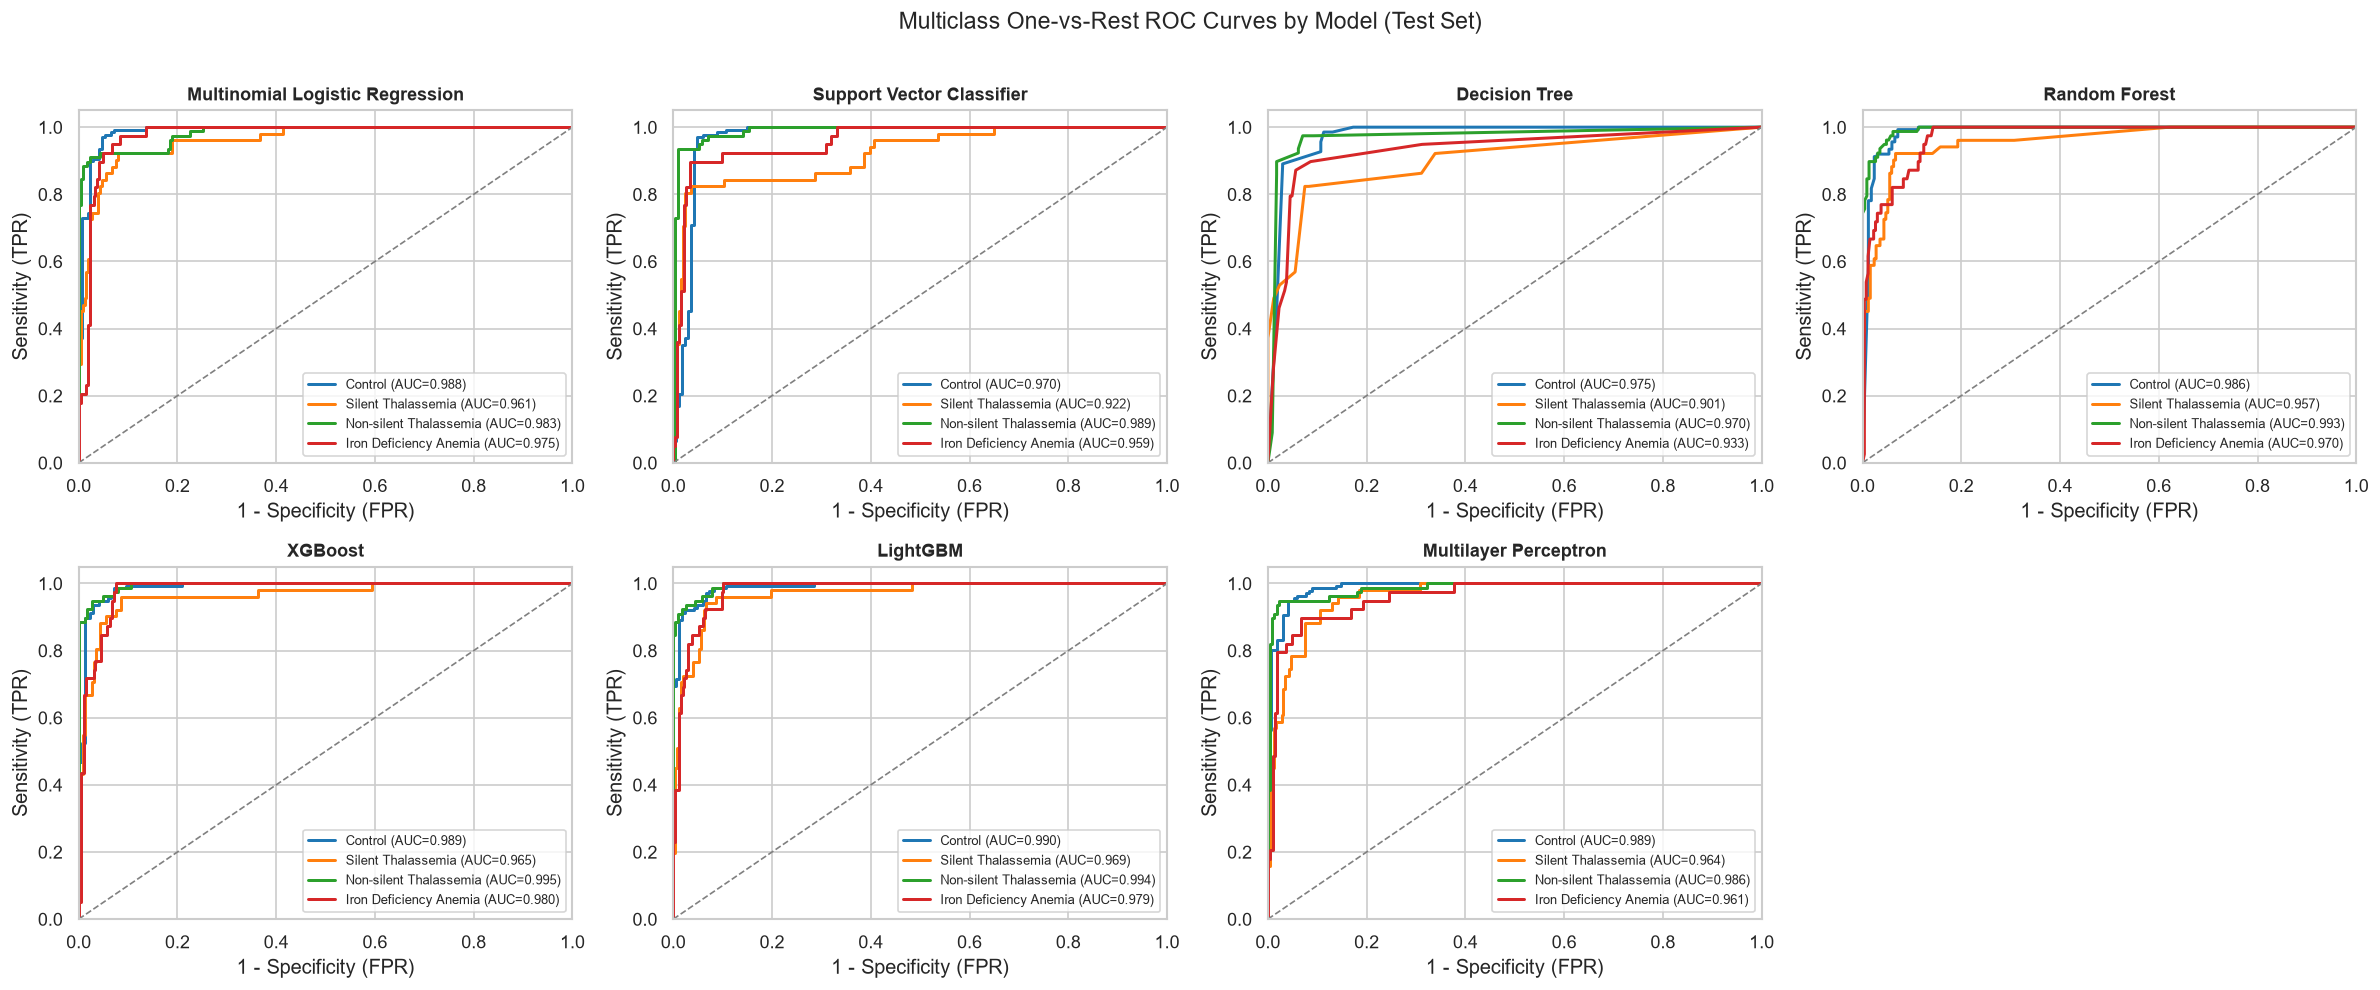

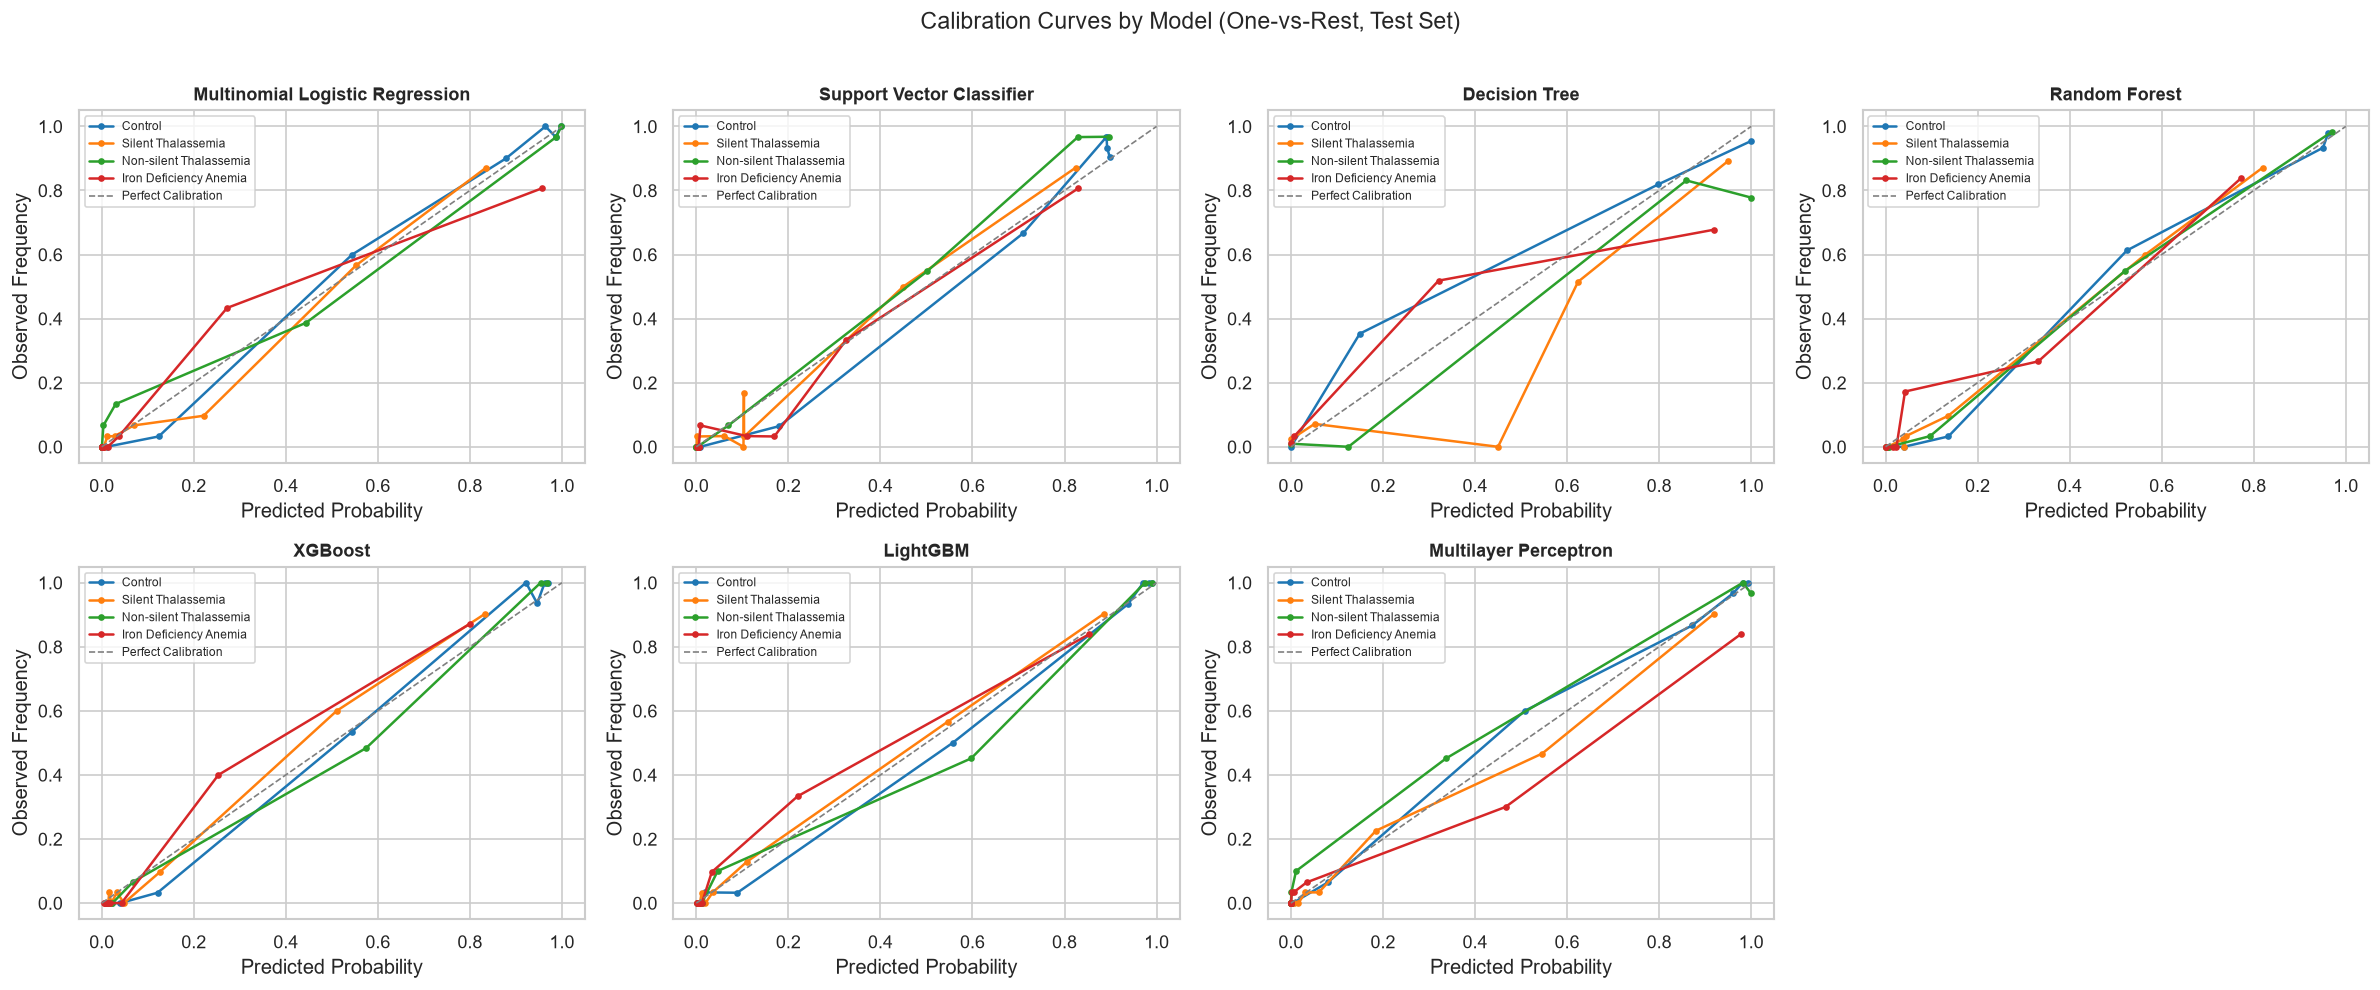

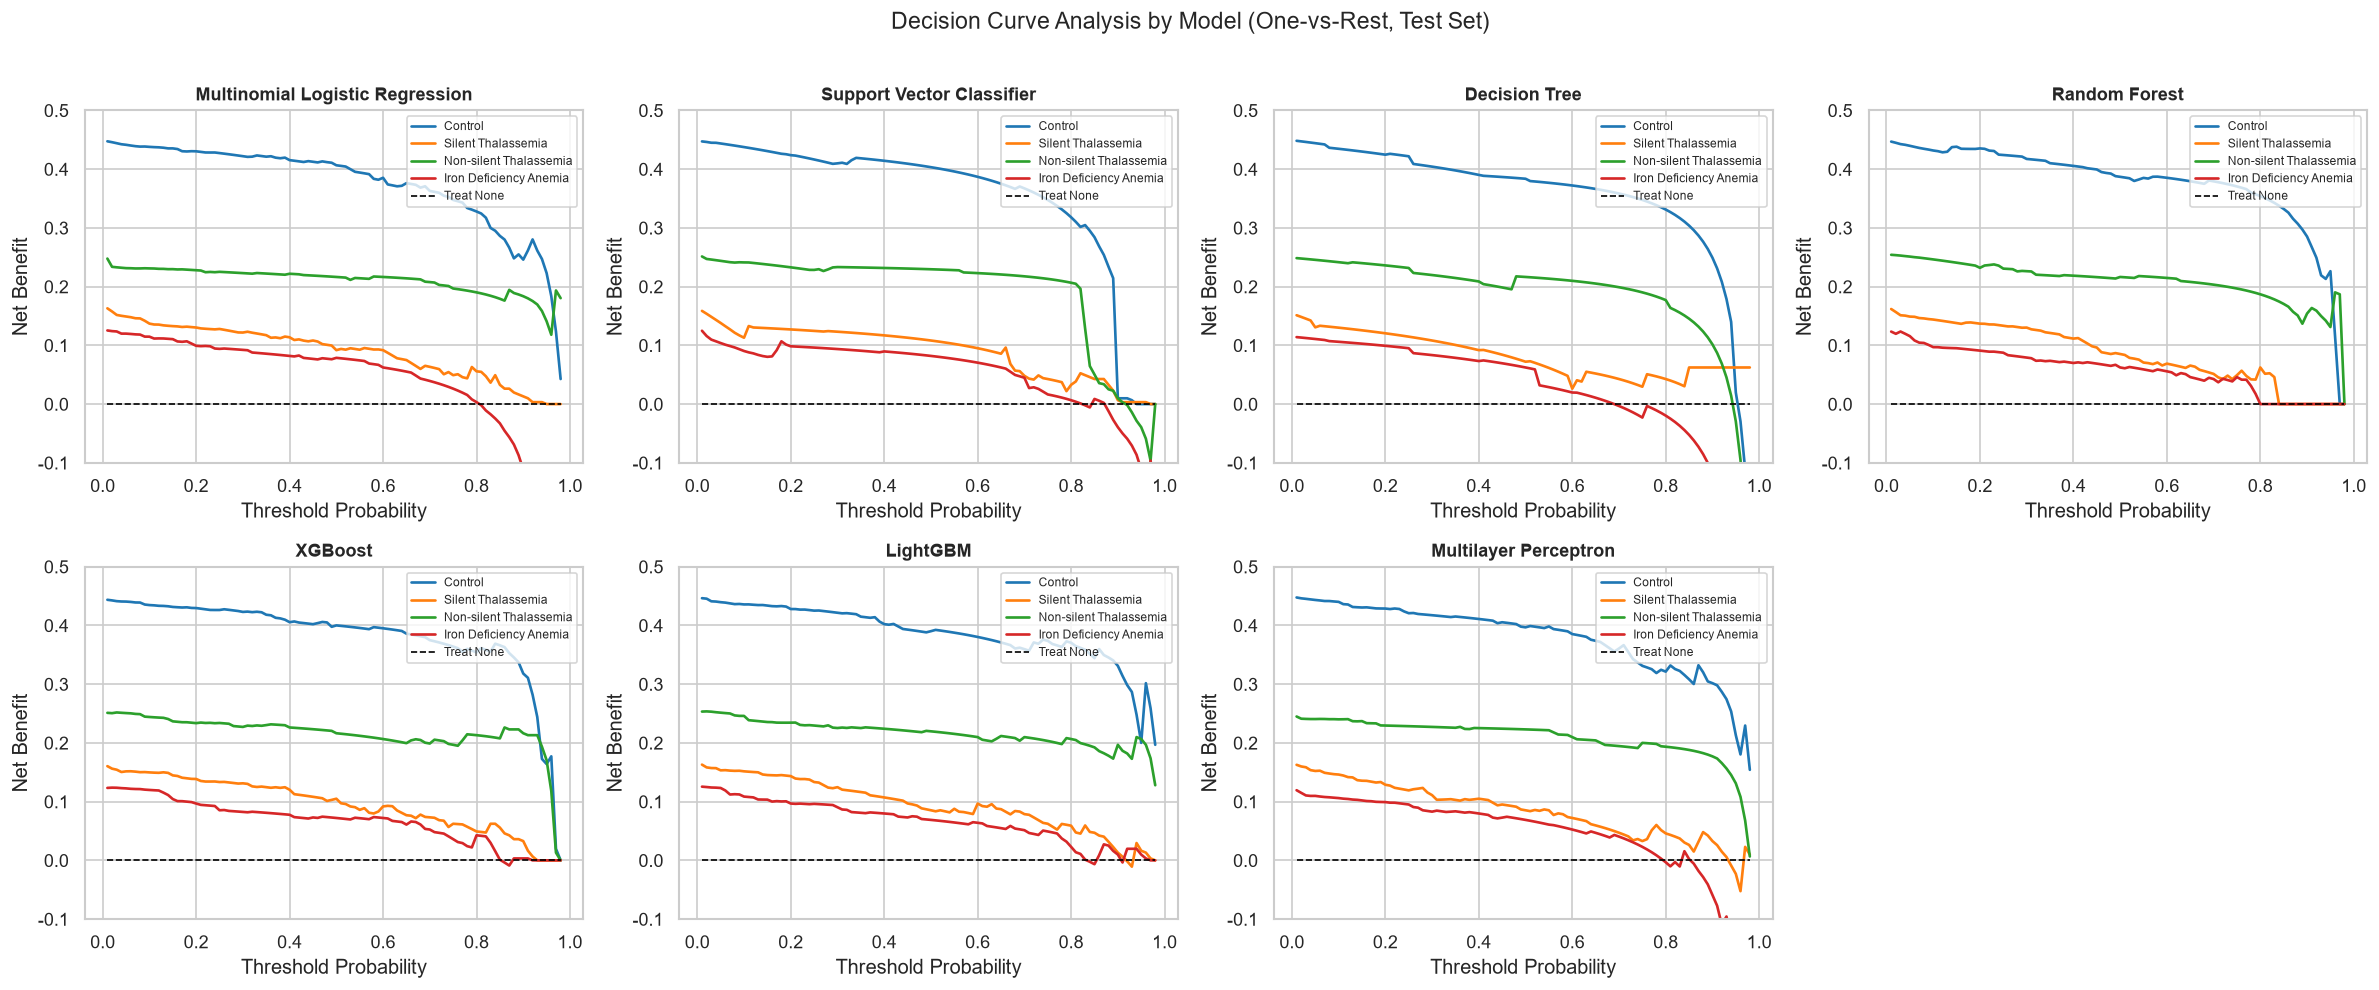

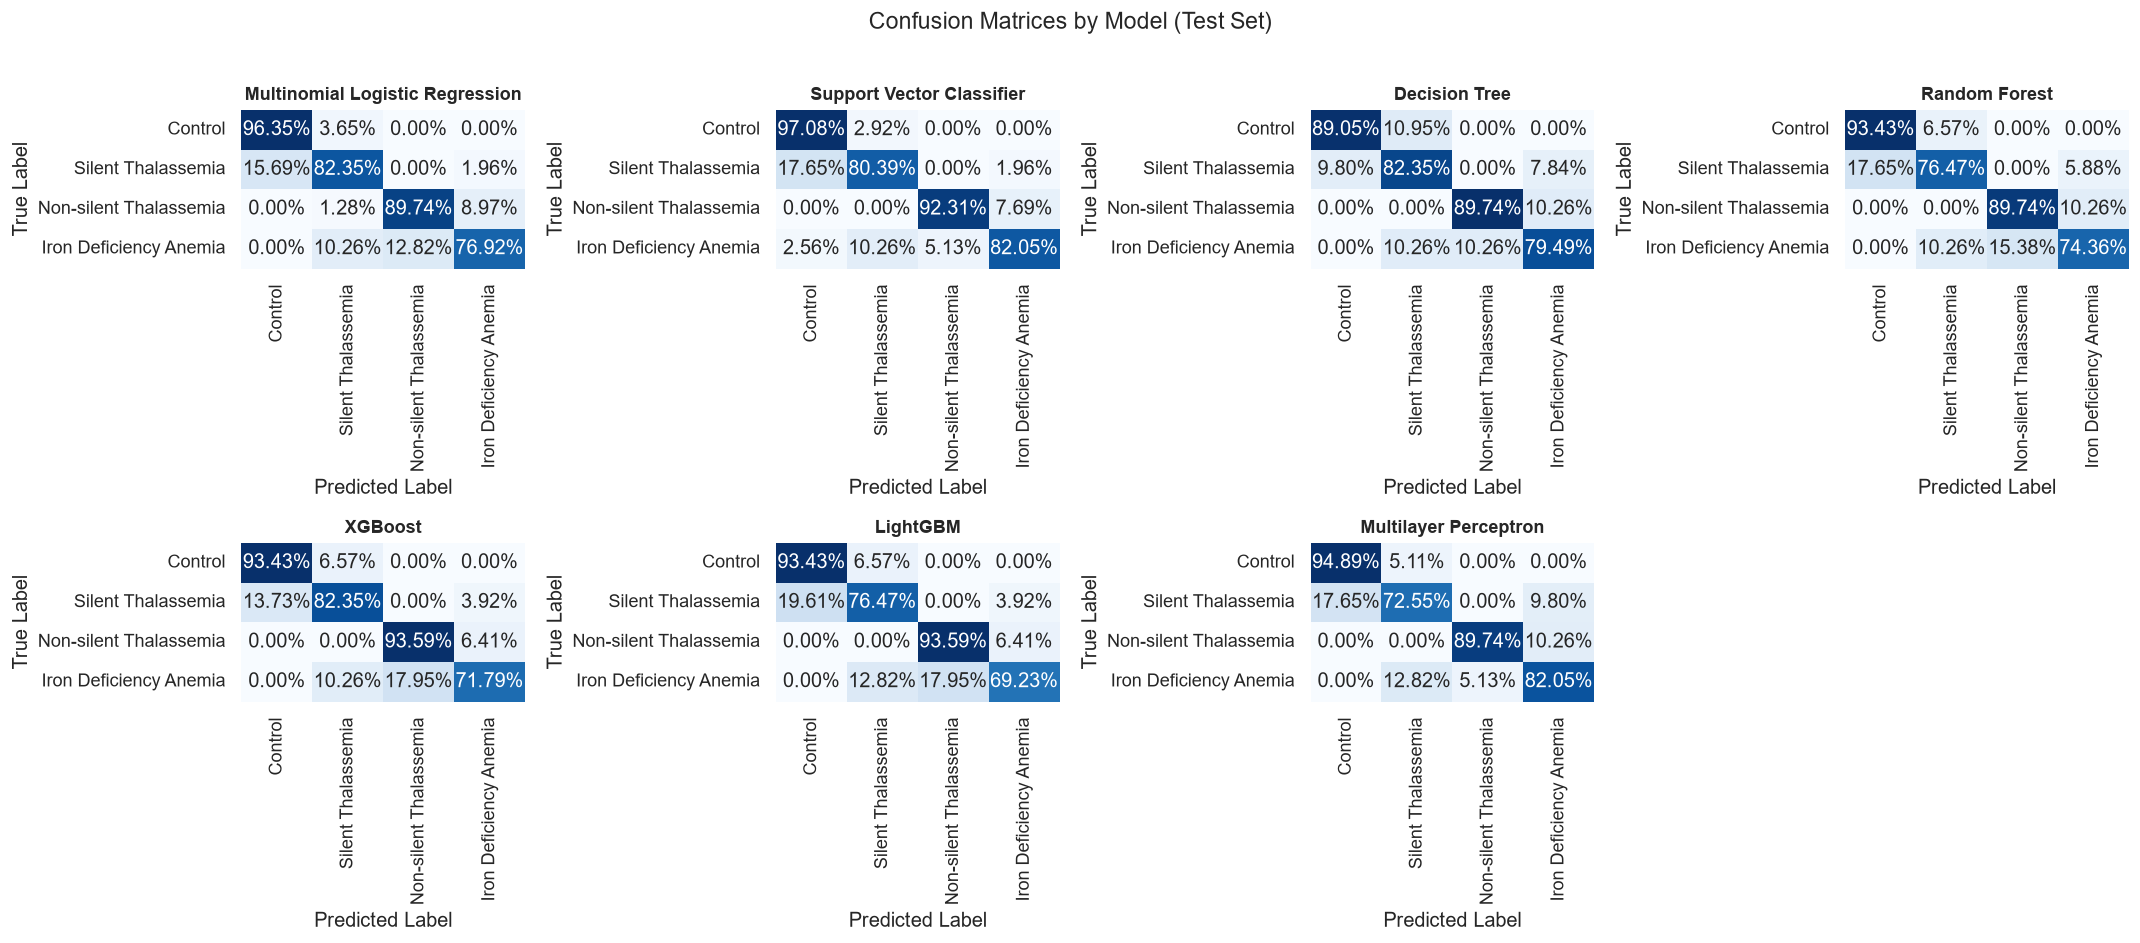

In [13]:
test_predictions = collect_test_predictions(trainers, X_test, y_test)
roc_input = {name: (v["y_true"], v["y_proba"]) for name, v in test_predictions.items()}
cm_input = {name: (v["y_true"], v["y_pred"]) for name, v in test_predictions.items()}

plot_roc_grid(roc_input, save_path=settings.FIGURE_DIR / "fig1_roc_curves.png")
plot_calibration_grid(roc_input, save_path=settings.FIGURE_DIR / "fig2_calibration_curves.png")
plot_decision_curve_grid(roc_input, save_path=settings.FIGURE_DIR / "fig3_decision_curves.png")
plot_confusion_matrix_grid(cm_input, save_path=settings.FIGURE_DIR / "fig4_confusion_matrices.png")

calibration_summary = compute_calibration_summary(roc_input)
calibration_summary.to_csv(
    settings.TABLE_DIR / "table5_calibration_slope_intercept.csv",
    index=False, encoding="utf-8-sig",
)
calibration_summary

## Step 11: SHAP Interpretability Analysis (Summary + Bar Plots)

In [3]:
# 背景数据从训练集中抽样，兼顾计算速度与精度
# 非树模型（LR/SVC/MLP）走模型无关的 Permutation Explainer，
# shap_plots.py 内部还会再自动下采样到 max_background 条，这里只需给出一个不太大的候选池
shap_background = X_train.sample(n=len(X_train), random_state=settings.RANDOM_STATE)
class_indexes = [0, 1, 2, 3]

for model_name in settings.SHAP_MODELS:
    if model_name not in trainers:
        continue

    for class_index in class_indexes:
        model_name_index = f'{model_name}_{class_index}'
        print(f"Computing SHAP values for {model_name_index} ...")
        generate_shap_report(
            pipeline=trainers[model_name].best_estimator_,
            X_background=shap_background,
            X_explain=X_test,
            feature_names=FEATURE_COLS,
            model_name=model_name_index,
            class_index=class_index,  # 默认解释"静止型地贫"类别, 可按需修改为 0/1/2/3
        )

Computing SHAP values for LogisticRegression_0 ...


PermutationExplainer explainer: 306it [00:30,  8.02it/s]                         


Computing SHAP values for LogisticRegression_1 ...


PermutationExplainer explainer: 306it [00:25,  7.22it/s]                         


Computing SHAP values for LogisticRegression_2 ...


...

PermutationExplainer explainer: 306it [00:56,  4.47it/s]                         


Computing SHAP values for MLP_2 ...


PermutationExplainer explainer: 306it [00:56,  4.42it/s]                         


Computing SHAP values for MLP_3 ...


PermutationExplainer explainer: 306it [00:58,  4.30it/s]                         


In [ ]:
print("\n" + "=" * 60)
print("Pipeline completed! Results saved to:")
print(f"  Tables: {settings.TABLE_DIR}")
print(f"  Figures: {settings.FIGURE_DIR}")
print(f"  Models: {settings.MODEL_DIR}")
print("=" * 60)